# 203 — Report figures and original-MOU front comparison

This notebook pulls together the results from Notebooks `201` and `202` and turns them into cleaner report-ready tables and figures.

The key distinction in this notebook is:

- **Fixed-design re-evaluation:** the same baseline Pareto-front designs are held fixed, and only transmissivity `T` is changed.
- **Original MOU comparison:** separate `05_MOU` optimization runs are compared for baseline `T`, `T −10%`, and `T +10%`.

That distinction is useful because the first view shows the **cost of being wrong about T for designs already selected**, while the second view shows how the **fully re-optimized tradeoff front itself moves** when the assumed T changes.


---
## 1. Imports, helper reload, and user controls

This section loads the shared helper script and sets the file paths/plot labels used throughout the notebook.

The helper reload lines are included on purpose. Jupyter can keep using an old version of `uncertainty_project_helpers.py` after you replace the file, so this notebook removes the old import from memory and reloads the helper from the current `Uncertainty_Project` folder.


In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Force Python/Jupyter to import the helper script from THIS notebook folder.
# -----------------------------------------------------------------------------
NOTEBOOK_DIR = Path.cwd().resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

sys.modules.pop("uncertainty_project_helpers", None)
importlib.invalidate_caches()

import uncertainty_project_helpers as up

# Confirm that the expected helper file is being used.
print("Imported helper from:", Path(up.__file__).resolve())
print("Helper version:", getattr(up, "HELPER_VERSION", "not reported"))

# Apply the shared plotting defaults. Edit up.PLOT_STYLE in the helper if you
# want project-wide figure changes, or override specific settings below.
up.apply_plot_style()

# -----------------------------------------------------------------------------
# User-editable settings
# -----------------------------------------------------------------------------
HISTORIC_STREAMFLOW_CFS = 8.6
PUMPING_COLUMN_FOR_HYDRO_PLOTS = "effective_total_pumping_cfs"

# These labels control the original MOU tradeoff CSVs that will be loaded.
# The helper searches:
#   1. this Uncertainty_Project folder,
#   2. the parent notebooks folder,
#   3. LPR_pycap_opt/notebooks/.
ORIGINAL_MOU_TRADEOFF_FILES = {
    "original_baseline": "fish_dollars_baseline_0.0_1.0_0.01_tradeoff.csv",
    "original_T_minus_10pct": "fish_dollars_Tmin10per_0.0_1.0_0.01_tradeoff.csv",
    "original_T_plus_10pct": "fish_dollars_Tplus10per_0.0_1.0_0.01_tradeoff.csv",
}

# Copy these dictionaries locally so you can change colors/labels in this
# notebook without editing the helper script.
SCENARIO_COLORS = up.SCENARIO_COLORS.copy()
SCENARIO_LABELS = up.SCENARIO_LABELS.copy()

# Use lighter colors for the original fully re-optimized fronts so they are
# visually distinct from the darker fixed-design re-evaluation lines.
SCENARIO_COLORS.update({
    "original_baseline": "#8FC3DA",        # lighter blue
    "original_T_minus_10pct": "#8BCB8B",  # lighter green
    "original_T_plus_10pct": "#E79AA5",   # lighter red/pink
})

# Standardized project paths.
PROJECT_DIR = up.find_lpr_pycap_opt_dir(NOTEBOOK_DIR)
dirs = up.make_project_dirs(NOTEBOOK_DIR, "203", "uncertainty_report_figures")
OUTPUT_DIR = dirs["output_dir"]
PROJECT_OUTPUT_DIR = NOTEBOOK_DIR / "project_output"

OUT201 = PROJECT_OUTPUT_DIR / "201_reevaluate_baseline_pareto_under_T_scenarios"
OUT202 = PROJECT_OUTPUT_DIR / "202_probability_weighted_T_uncertainty_cost"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUT201:", OUT201)
print("OUT202:", OUT202)
print("OUTPUT_DIR:", OUTPUT_DIR)


Imported helper from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/uncertainty_project_helpers.py
Helper version: 2026-05-19_202_203_normal_distribution_plot_fix
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUT201: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios
OUT202: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/202_probability_weighted_T_uncertainty_cost
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures


---
## 2. Load the 201 and 202 result files

Notebook `201` provides the known-error scenario results for `T −10%`, baseline `T`, and `T +10%`.

Notebook `202` provides the probability-weighted uncertainty results across many possible `T` values.


In [2]:
# -----------------------------------------------------------------------------
# Required inputs from 201 and 202.
# -----------------------------------------------------------------------------
required_paths = [
    OUT201 / "201_T_scenario_reevaluation_wide.csv",
    OUT201 / "201_T_scenario_summary.csv",
    OUT202 / "202_probability_weighted_member_summary.csv",
    OUT202 / "202_probability_weighted_overall_summary.csv",
    OUT202 / "202_T_probability_scenario_summary.csv",
    OUT202 / "202_T_probability_weights.csv",
]

missing = [p for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required files. Run notebooks 201 and 202 first.\n\n" +
        "\n".join(str(p) for p in missing)
    )

# Read result tables.
known_wide = pd.read_csv(OUT201 / "201_T_scenario_reevaluation_wide.csv")
known_summary = pd.read_csv(OUT201 / "201_T_scenario_summary.csv")
prob_members = pd.read_csv(OUT202 / "202_probability_weighted_member_summary.csv")
prob_overall = pd.read_csv(OUT202 / "202_probability_weighted_overall_summary.csv")
prob_scenarios = pd.read_csv(OUT202 / "202_T_probability_scenario_summary.csv")
prob_weights = pd.read_csv(OUT202 / "202_T_probability_weights.csv")



# -----------------------------------------------------------------------------
# Make the 201 summary table backward-compatible with older 201 outputs.
# -----------------------------------------------------------------------------
# Earlier versions of Notebook 201 saved a scenario summary that did not include
# the baseline-relative metrics used by this report notebook. Instead of forcing
# you to rerun Notebook 201, we reconstruct those missing columns here from the
# wide member-level output. This keeps 203 compatible with both older and newer
# 201 result folders.
def add_missing_known_summary_metrics(summary_df: pd.DataFrame, wide_df: pd.DataFrame) -> pd.DataFrame:
    """Add baseline-relative known-T metrics if an older 201 summary lacks them."""
    summary = summary_df.copy()

    # These columns are scenario-specific values in the wide dataframe.
    scenario_to_stream_col = {
        "T_minus_10pct": "streamflow_cfs__T_minus_10pct",
        "baseline_T": "streamflow_cfs__baseline_T",
        "T_plus_10pct": "streamflow_cfs__T_plus_10pct",
    }
    scenario_to_depletion_col = {
        "T_minus_10pct": "depletion_cfs__T_minus_10pct",
        "baseline_T": "depletion_cfs__baseline_T",
        "T_plus_10pct": "depletion_cfs__T_plus_10pct",
    }

    baseline_stream_col = scenario_to_stream_col["baseline_T"]
    if baseline_stream_col not in wide_df.columns:
        raise KeyError(
            f"Cannot reconstruct 201 summary metrics because {baseline_stream_col!r} "
            "is missing from 201_T_scenario_reevaluation_wide.csv."
        )

    baseline_stream = pd.to_numeric(wide_df[baseline_stream_col], errors="coerce")
    baseline_mean_stream = baseline_stream.mean()

    for col in [
        "mean_streamflow_change_from_baseline_cfs",
        "mean_absolute_streamflow_error_cfs",
        "max_absolute_streamflow_error_cfs",
        "mean_streamflow_shortfall_below_baseline_cfs",
        "max_streamflow_shortfall_below_baseline_cfs",
    ]:
        if col not in summary.columns:
            summary[col] = np.nan

    for idx, row in summary.iterrows():
        scen = row["scenario"]
        stream_col = scenario_to_stream_col.get(scen)
        depletion_col = scenario_to_depletion_col.get(scen)

        # Fall back to summary means if this scenario is not in the wide table.
        if stream_col is None or stream_col not in wide_df.columns:
            if "mean_streamflow_cfs" in summary.columns:
                summary.loc[idx, "mean_streamflow_change_from_baseline_cfs"] = (
                    row["mean_streamflow_cfs"] - baseline_mean_stream
                )
            continue

        scen_stream = pd.to_numeric(wide_df[stream_col], errors="coerce")
        error = baseline_stream - scen_stream  # positive = scenario streamflow lower than baseline-T prediction
        abs_error = error.abs()
        shortfall = error.clip(lower=0)

        summary.loc[idx, "mean_streamflow_change_from_baseline_cfs"] = scen_stream.mean() - baseline_mean_stream
        summary.loc[idx, "mean_absolute_streamflow_error_cfs"] = abs_error.mean()
        summary.loc[idx, "max_absolute_streamflow_error_cfs"] = abs_error.max()
        summary.loc[idx, "mean_streamflow_shortfall_below_baseline_cfs"] = shortfall.mean()
        summary.loc[idx, "max_streamflow_shortfall_below_baseline_cfs"] = shortfall.max()

        # Also reconstruct mean streamflow/depletion if those happen to be missing.
        if "mean_streamflow_cfs" not in summary.columns:
            summary.loc[idx, "mean_streamflow_cfs"] = scen_stream.mean()
        if "mean_depletion_cfs" not in summary.columns and depletion_col in wide_df.columns:
            summary.loc[idx, "mean_depletion_cfs"] = pd.to_numeric(wide_df[depletion_col], errors="coerce").mean()

    return summary

known_summary = add_missing_known_summary_metrics(known_summary, known_wide)

# Sort by pumping so line plots draw from left to right along the tradeoff front.
known_wide = known_wide.sort_values(PUMPING_COLUMN_FOR_HYDRO_PLOTS).reset_index(drop=True)
prob_members = prob_members.sort_values(PUMPING_COLUMN_FOR_HYDRO_PLOTS).reset_index(drop=True)

print("Known T scenario rows:", len(known_wide))
print("Probability-weighted member rows:", len(prob_members))
print("T probability scenarios:", len(prob_weights))

display(known_summary)
display(prob_overall)


Known T scenario rows: 174
Probability-weighted member rows: 174
T probability scenarios: 11


,scenario,T_factor,T_value,n_members,mean_effective_total_pumping_cfs,mean_depletion_cfs,mean_streamflow_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,T_minus_10pct,0.9,1530.0,174,107.288405,2.544795,6.055205,0.160708,0.160708,0.254155,0.000000,0.000000
1,baseline_T,1.0,1700.0,174,107.288405,2.705503,5.894497,0.000000,0.000000,0.000000,0.000000,0.000000
2,T_plus_10pct,1.1,1870.0,174,107.288405,2.856156,5.743844,-0.150653,0.150653,0.235821,0.150653,0.235821


,metric,value
0,n_members,174.000000
1,mean_probability_weighted_absolute_streamflow_...,0.114961
2,max_probability_weighted_absolute_streamflow_e...,0.180857
3,mean_probability_weighted_streamflow_shortfall...,0.055357
4,max_probability_weighted_streamflow_shortfall_cfs,0.086574
5,mean_streamflow_std_cfs,0.143166
6,max_streamflow_std_cfs,0.225284
7,mean_probability_streamflow_lower_than_baseline,0.418016
8,mean_probability_streamflow_below_threshold,NaN


---
## 3. Build compact report tables

The full CSVs are useful for reproducibility, but the final report needs a compact summary table. This section creates:

1. a short known-error/probability-weighted summary, and  
2. a representative-design table for a few important Pareto-front positions.


In [3]:
# -----------------------------------------------------------------------------
# Helper functions for compact summaries.
# -----------------------------------------------------------------------------
def scalar_from_overall(metric_name: str) -> float:
    """Fetch one scalar metric from the 202 overall summary table."""
    row = prob_overall.loc[prob_overall["metric"] == metric_name, "value"]
    return np.nan if row.empty else float(row.iloc[0])


def scenario_row(label: str) -> pd.Series:
    """Fetch one scenario row from the 201 summary table."""
    rows = known_summary.loc[known_summary["scenario"] == label]
    if rows.empty:
        raise KeyError(f"Missing scenario {label!r} from known_summary.")
    return rows.iloc[0]

baseline_row = scenario_row("baseline_T")
tminus_row = scenario_row("T_minus_10pct")
tplus_row = scenario_row("T_plus_10pct")

# Compact table that can be copied directly into your report/results section.
compact_summary = pd.DataFrame([
    {
        "analysis": "Known error: T −10%",
        "T_value": tminus_row["T_value"],
        "mean_streamflow_cfs": tminus_row["mean_streamflow_cfs"],
        "mean_depletion_cfs": tminus_row["mean_depletion_cfs"],
        "mean_streamflow_change_from_baseline_cfs": tminus_row["mean_streamflow_change_from_baseline_cfs"],
        "mean_cost_metric_cfs": tminus_row["mean_streamflow_shortfall_below_baseline_cfs"],
        "max_cost_metric_cfs": tminus_row["max_streamflow_shortfall_below_baseline_cfs"],
    },
    {
        "analysis": "Known error: T +10%",
        "T_value": tplus_row["T_value"],
        "mean_streamflow_cfs": tplus_row["mean_streamflow_cfs"],
        "mean_depletion_cfs": tplus_row["mean_depletion_cfs"],
        "mean_streamflow_change_from_baseline_cfs": tplus_row["mean_streamflow_change_from_baseline_cfs"],
        "mean_cost_metric_cfs": tplus_row["mean_streamflow_shortfall_below_baseline_cfs"],
        "max_cost_metric_cfs": tplus_row["max_streamflow_shortfall_below_baseline_cfs"],
    },
    {
        "analysis": "Unknown T: probability-weighted",
        "T_value": np.nan,
        "mean_streamflow_cfs": prob_members["expected_streamflow_cfs"].mean(),
        "mean_depletion_cfs": prob_members["expected_depletion_cfs"].mean(),
        "mean_streamflow_change_from_baseline_cfs": prob_members["expected_streamflow_bias_from_baseline_cfs"].mean(),
        "mean_cost_metric_cfs": scalar_from_overall("mean_probability_weighted_streamflow_shortfall_cfs"),
        "max_cost_metric_cfs": scalar_from_overall("max_probability_weighted_streamflow_shortfall_cfs"),
    },
])

compact_summary.to_csv(OUTPUT_DIR / "203_compact_uncertainty_summary.csv", index=False)
display(compact_summary)


,analysis,T_value,mean_streamflow_cfs,mean_depletion_cfs,mean_streamflow_change_from_baseline_cfs,mean_cost_metric_cfs,max_cost_metric_cfs
0,Known error: T −10%,1530.0,6.055205,2.544795,0.160708,0.000000,0.000000
1,Known error: T +10%,1870.0,5.743844,2.856156,-0.150653,0.150653,0.235821
2,Unknown T: probability-weighted,NaN,5.898743,2.701257,0.004247,0.055357,0.086574


---
## 4. Select representative Pareto-front designs

This section identifies a few representative designs from the baseline Pareto front.

The “normalized compromise knee” is a simple report-friendly choice: it finds the design closest to the ideal corner after normalizing pumping and streamflow to 0–1 scales. It is not the only possible knee-point definition, but it is useful for explaining one representative tradeoff solution.


In [4]:
# -----------------------------------------------------------------------------
# Representative design selection.
# -----------------------------------------------------------------------------
def normalize_01(series: pd.Series) -> pd.Series:
    """Normalize a pandas Series to the 0–1 range."""
    span = series.max() - series.min()
    if span == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / span

rep = prob_members.copy()

# For this tradeoff, higher pumping and higher streamflow are generally the
# desirable directions. The normalized distance below gives a simple compromise
# point between those two competing goals.
rep["pumping_norm"] = normalize_01(rep[PUMPING_COLUMN_FOR_HYDRO_PLOTS])
rep["streamflow_norm"] = normalize_01(rep["baseline_T_streamflow_cfs"])
rep["distance_to_ideal"] = np.sqrt((1 - rep["pumping_norm"])**2 + (1 - rep["streamflow_norm"])**2)

idxs = {
    "lowest_pumping": rep[PUMPING_COLUMN_FOR_HYDRO_PLOTS].idxmin(),
    "highest_pumping": rep[PUMPING_COLUMN_FOR_HYDRO_PLOTS].idxmax(),
    "highest_streamflow": rep["baseline_T_streamflow_cfs"].idxmax(),
    "lowest_streamflow": rep["baseline_T_streamflow_cfs"].idxmin(),
    "normalized_compromise_knee": rep["distance_to_ideal"].idxmin(),
}

representative_designs = []
for label, idx in idxs.items():
    row = rep.loc[idx].copy()
    row["representative_design"] = label
    representative_designs.append(row)

representative_designs = pd.DataFrame(representative_designs)

# Keep only the most report-useful columns.
representative_cols = [
    "representative_design", "member", PUMPING_COLUMN_FOR_HYDRO_PLOTS,
    "baseline_T_streamflow_cfs", "baseline_T_depletion_cfs",
    "expected_streamflow_cfs", "streamflow_std_cfs", "streamflow_p05_cfs", "streamflow_p95_cfs",
    "probability_weighted_absolute_streamflow_error_cfs",
    "probability_weighted_streamflow_shortfall_cfs",
    "max_streamflow_shortfall_below_baseline_cfs",
]
representative_designs = representative_designs[[c for c in representative_cols if c in representative_designs.columns]]

representative_designs.to_csv(OUTPUT_DIR / "203_representative_pareto_designs.csv", index=False)
display(representative_designs)


,representative_design,member,effective_total_pumping_cfs,baseline_T_streamflow_cfs,baseline_T_depletion_cfs,expected_streamflow_cfs,streamflow_std_cfs,streamflow_p05_cfs,streamflow_p95_cfs,probability_weighted_absolute_streamflow_error_cfs,probability_weighted_streamflow_shortfall_cfs,max_streamflow_shortfall_below_baseline_cfs
0,lowest_pumping,gen=47_member=5907_pso,92.989031,7.175175,1.424825,7.177078,0.082310,7.024438,7.301003,0.066115,0.032106,0.170882
173,highest_pumping,35,117.415657,3.805159,4.794841,3.812868,0.225284,3.402097,4.154954,0.180857,0.086574,0.455635
0,highest_streamflow,gen=47_member=5907_pso,92.989031,7.175175,1.424825,7.177078,0.082310,7.024438,7.301003,0.066115,0.032106,0.170882
172,lowest_streamflow,56,117.275577,3.802680,4.797320,3.810298,0.224233,3.401268,4.150717,0.180017,0.086199,0.453765
83,normalized_compromise_knee,gen=32_member=3978_pso,108.891590,6.146686,2.453314,6.150878,0.133246,5.906973,6.352795,0.106992,0.051400,0.271133


---
## 5. Combined fixed-design vs re-optimized-front comparison

This combined figure is useful for explaining the difference between the two major views of the project:

- the **top row** shows fixed baseline designs re-evaluated under different T values, and
- the **bottom row** shows the original fully re-optimized MOU fronts.

This helps separate “performance of existing selected designs if T is wrong” from “how the optimal front moves if the model is re-optimized under a different T.”


Original MOU tradeoff rows loaded: 614


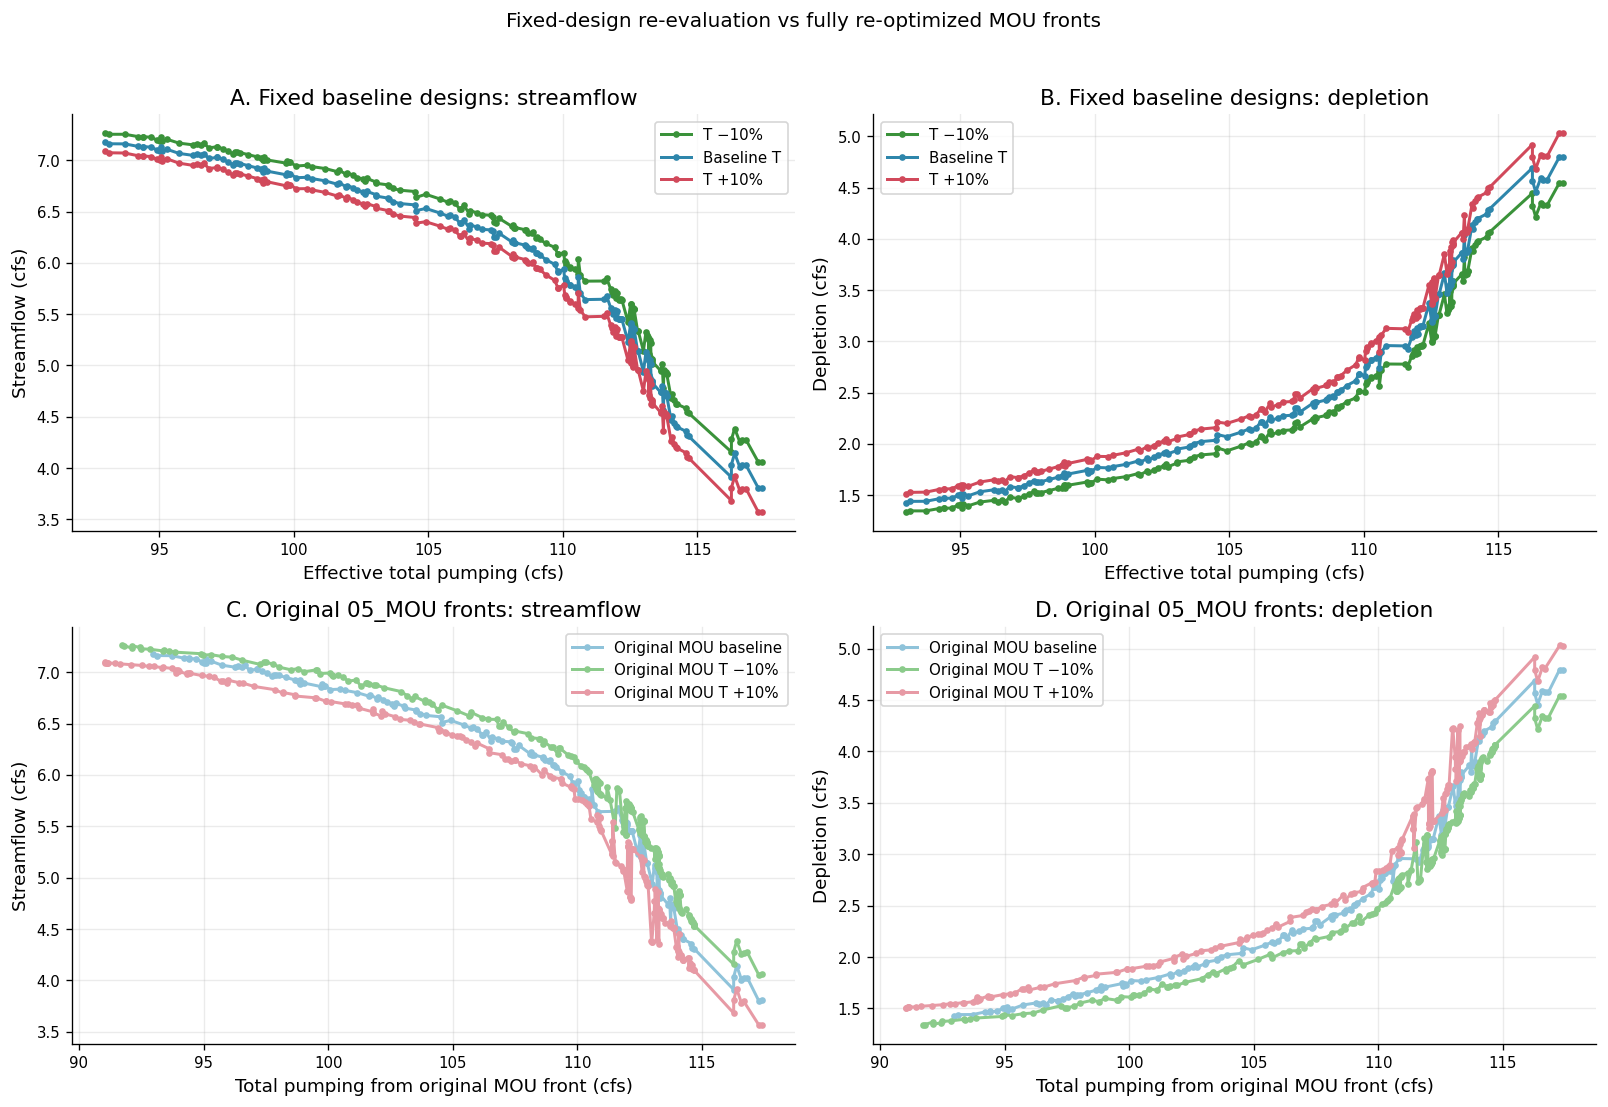

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures/203_fixed_design_vs_original_MOU_fronts_2x2.png


In [5]:
# -----------------------------------------------------------------------------
# Load original fully optimized MOU tradeoff fronts.
# -----------------------------------------------------------------------------
original_tradeoffs = up.load_original_mou_tradeoff_fronts(
    project_dir=PROJECT_DIR,
    notebook_dir=NOTEBOOK_DIR,
    tradeoff_files=ORIGINAL_MOU_TRADEOFF_FILES,
)

print("Original MOU tradeoff rows loaded:", len(original_tradeoffs))


# -----------------------------------------------------------------------------
# Combined 2x2 figure: fixed-design re-evaluation vs original re-optimized MOU.
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0))
ax_a, ax_b, ax_c, ax_d = axes.ravel()

# Top-left: fixed designs, streamflow.
fixed_plot = up.sort_for_plot(known_wide, PUMPING_COLUMN_FOR_HYDRO_PLOTS)
for scen, ycol in {
    "T_minus_10pct": "streamflow_cfs__T_minus_10pct",
    "baseline_T": "streamflow_cfs__baseline_T",
    "T_plus_10pct": "streamflow_cfs__T_plus_10pct",
}.items():
    if ycol in fixed_plot.columns:
        ax_a.plot(
            fixed_plot[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            fixed_plot[ycol],
            marker="o",
            markersize=3,
            color=SCENARIO_COLORS.get(scen),
            label=SCENARIO_LABELS.get(scen, scen),
        )
ax_a.set_title("A. Fixed baseline designs: streamflow")
ax_a.set_xlabel("Effective total pumping (cfs)")
ax_a.set_ylabel("Streamflow (cfs)")
ax_a.legend(loc="best")

# Top-right: fixed designs, depletion.
for scen, ycol in {
    "T_minus_10pct": "depletion_cfs__T_minus_10pct",
    "baseline_T": "depletion_cfs__baseline_T",
    "T_plus_10pct": "depletion_cfs__T_plus_10pct",
}.items():
    if ycol in fixed_plot.columns:
        ax_b.plot(
            fixed_plot[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            fixed_plot[ycol],
            marker="o",
            markersize=3,
            color=SCENARIO_COLORS.get(scen),
            label=SCENARIO_LABELS.get(scen, scen),
        )
ax_b.set_title("B. Fixed baseline designs: depletion")
ax_b.set_xlabel("Effective total pumping (cfs)")
ax_b.set_ylabel("Depletion (cfs)")
ax_b.legend(loc="best")

# Bottom row: original MOU re-optimized fronts, if available.
if original_tradeoffs.empty:
    for ax, title in [(ax_c, "C. Original MOU fronts: streamflow"), (ax_d, "D. Original MOU fronts: depletion")]:
        ax.text(0.5, 0.5, "Original MOU tradeoff CSVs\nnot found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        ax.set_xlabel("Total pumping (cfs)")
else:
    for scen, group in original_tradeoffs.groupby("scenario", sort=False):
        group = group.sort_values("total_pumping_cfs")
        color = SCENARIO_COLORS.get(scen)
        label = SCENARIO_LABELS.get(scen, scen)
        ax_c.plot(group["total_pumping_cfs"], group["streamflow_cfs"], marker="o", markersize=3, color=color, label=label)
        ax_d.plot(group["total_pumping_cfs"], group["depletion_cfs"], marker="o", markersize=3, color=color, label=label)
    ax_c.set_title("C. Original 05_MOU fronts: streamflow")
    ax_c.set_xlabel("Total pumping from original MOU front (cfs)")
    ax_c.set_ylabel("Streamflow (cfs)")
    ax_c.legend(loc="best")
    ax_d.set_title("D. Original 05_MOU fronts: depletion")
    ax_d.set_xlabel("Total pumping from original MOU front (cfs)")
    ax_d.set_ylabel("Depletion (cfs)")
    ax_d.legend(loc="best")

fig.suptitle("Fixed-design re-evaluation vs fully re-optimized MOU fronts", y=1.02)
up.save_figure(fig, OUTPUT_DIR / "203_fixed_design_vs_original_MOU_fronts_2x2.png")


---
## 6. Scenario-by-scenario comparison of original MOU fronts and fixed-design re-evaluations

This section compares the **original fully re-optimized 05_MOU Pareto fronts** against the **fixed baseline-design re-evaluations** from Notebook 201.

The key distinction is:

- **Original MOU front:** the optimization was rerun under that T scenario.
- **Fixed-design re-evaluation:** the baseline Pareto pumping designs were held fixed, then re-evaluated under that T scenario.

The 1×3 layout keeps each T scenario separate so the original and re-evaluated fronts can be compared directly for T −10%, baseline T, and T +10%.


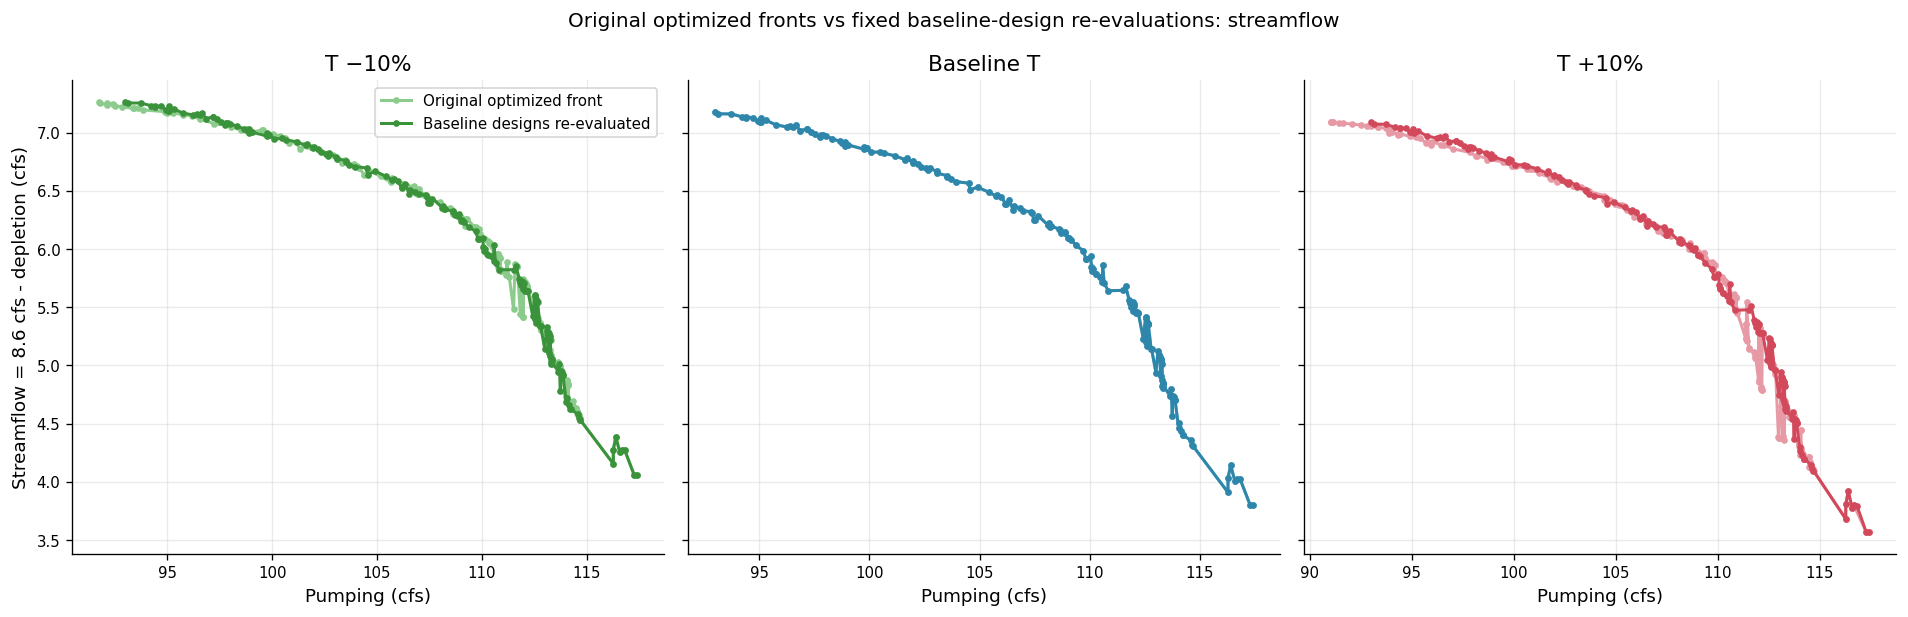

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures/203_original_vs_reevaluated_fronts_streamflow_1x3.png


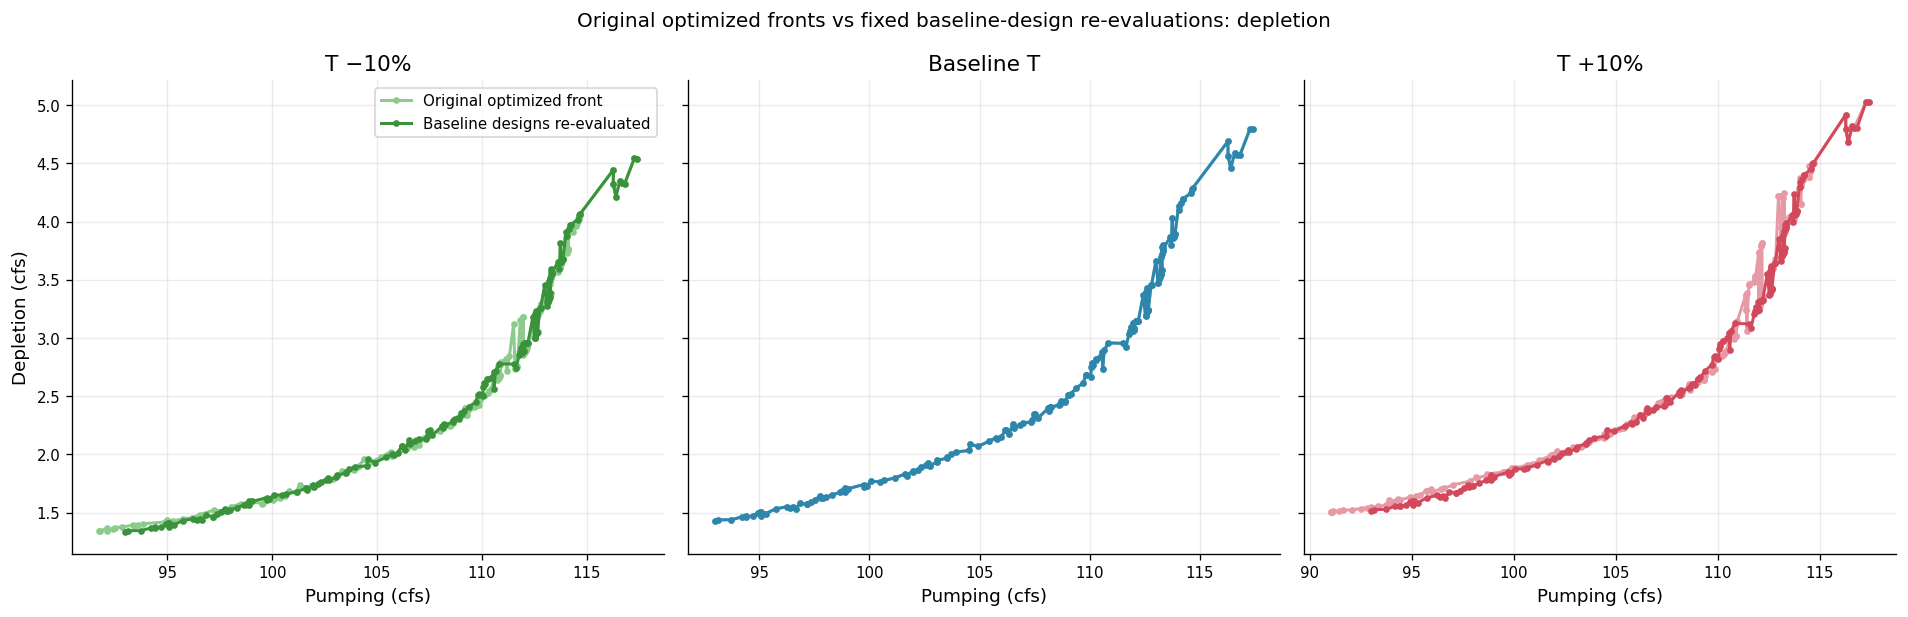

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures/203_original_vs_reevaluated_fronts_depletion_1x3.png


In [6]:
# -----------------------------------------------------------------------------
# Scenario-by-scenario comparison:
# original fully re-optimized fronts vs fixed baseline-design re-evaluations.
# -----------------------------------------------------------------------------
# This section creates two 1x3 figures:
#   1. streamflow vs pumping
#   2. depletion vs pumping
#
# Each column is one T scenario:
#   - T −10%
#   - baseline T
#   - T +10%
#
# Within each panel:
#   - lighter line = original 05_MOU front for that T scenario
#   - darker line  = baseline Pareto designs re-evaluated under that T scenario

scenario_pairs = [
    {
        "title": "T −10%",
        "reeval_label": "T_minus_10pct",
        "original_label": "original_T_minus_10pct",
        "stream_col": "streamflow_cfs__T_minus_10pct",
        "depl_col": "depletion_cfs__T_minus_10pct",
    },
    {
        "title": "Baseline T",
        "reeval_label": "baseline_T",
        "original_label": "original_baseline",
        "stream_col": "streamflow_cfs__baseline_T",
        "depl_col": "depletion_cfs__baseline_T",
    },
    {
        "title": "T +10%",
        "reeval_label": "T_plus_10pct",
        "original_label": "original_T_plus_10pct",
        "stream_col": "streamflow_cfs__T_plus_10pct",
        "depl_col": "depletion_cfs__T_plus_10pct",
    },
]

# Re-evaluated baseline designs from Notebook 201.
fixed_plot = up.sort_for_plot(known_wide, PUMPING_COLUMN_FOR_HYDRO_PLOTS)

# -----------------------------------------------------------------------------
# 6A. Streamflow comparison: original optimized fronts vs fixed-design re-evaluations
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True)

for ax, spec in zip(axes, scenario_pairs):
    reeval_label = spec["reeval_label"]
    original_label = spec["original_label"]
    stream_col = spec["stream_col"]

    # Original MOU front: fully re-optimized under that T scenario.
    if not original_tradeoffs.empty:
        original_group = original_tradeoffs.loc[
            original_tradeoffs["scenario"] == original_label
        ].copy()

        if not original_group.empty:
            original_group = original_group.sort_values("total_pumping_cfs")
            ax.plot(
                original_group["total_pumping_cfs"],
                original_group["streamflow_cfs"],
                marker="o",
                markersize=3,
                linewidth=1.8,
                color=SCENARIO_COLORS.get(original_label),
                label="Original optimized front",
            )

    # Re-evaluated baseline designs: same baseline Pareto members, alternate T.
    if stream_col in fixed_plot.columns:
        ax.plot(
            fixed_plot[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            fixed_plot[stream_col],
            marker="o",
            markersize=3,
            linewidth=1.8,
            color=SCENARIO_COLORS.get(reeval_label),
            label="Baseline designs re-evaluated",
        )

    ax.set_title(spec["title"])
    ax.set_xlabel("Pumping (cfs)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Streamflow = 8.6 cfs - depletion (cfs)")
axes[0].legend(loc="best")

fig.suptitle(
    "Original optimized fronts vs fixed baseline-design re-evaluations: streamflow",
    y=0.98,
)
up.save_figure(
    fig,
    OUTPUT_DIR / "203_original_vs_reevaluated_fronts_streamflow_1x3.png",
)

# -----------------------------------------------------------------------------
# 6B. Depletion comparison: original optimized fronts vs fixed-design re-evaluations
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True)

for ax, spec in zip(axes, scenario_pairs):
    reeval_label = spec["reeval_label"]
    original_label = spec["original_label"]
    depl_col = spec["depl_col"]

    # Original MOU front: fully re-optimized under that T scenario.
    if not original_tradeoffs.empty:
        original_group = original_tradeoffs.loc[
            original_tradeoffs["scenario"] == original_label
        ].copy()

        if not original_group.empty:
            original_group = original_group.sort_values("total_pumping_cfs")
            ax.plot(
                original_group["total_pumping_cfs"],
                original_group["depletion_cfs"],
                marker="o",
                markersize=3,
                linewidth=1.8,
                color=SCENARIO_COLORS.get(original_label),
                label="Original optimized front",
            )

    # Re-evaluated baseline designs: same baseline Pareto members, alternate T.
    if depl_col in fixed_plot.columns:
        ax.plot(
            fixed_plot[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            fixed_plot[depl_col],
            marker="o",
            markersize=3,
            linewidth=1.8,
            color=SCENARIO_COLORS.get(reeval_label),
            label="Baseline designs re-evaluated",
        )

    ax.set_title(spec["title"])
    ax.set_xlabel("Pumping (cfs)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Depletion (cfs)")
axes[0].legend(loc="best")

fig.suptitle(
    "Original optimized fronts vs fixed baseline-design re-evaluations: depletion",
    y=0.98,
)
up.save_figure(
    fig,
    OUTPUT_DIR / "203_original_vs_reevaluated_fronts_depletion_1x3.png",
)


---
## 7. Fixed baseline-design response to known transmissivity error

This figure summarizes how the **baseline Pareto-front designs** respond when the designs are held fixed and T is changed.

The top row shows the direct hydrologic response:

- streamflow vs pumping
- depletion vs pumping

The bottom row shows the error relative to the baseline-T prediction:

- signed streamflow change
- absolute streamflow error

This helps show both the direction and magnitude of the known ±10% T effect.


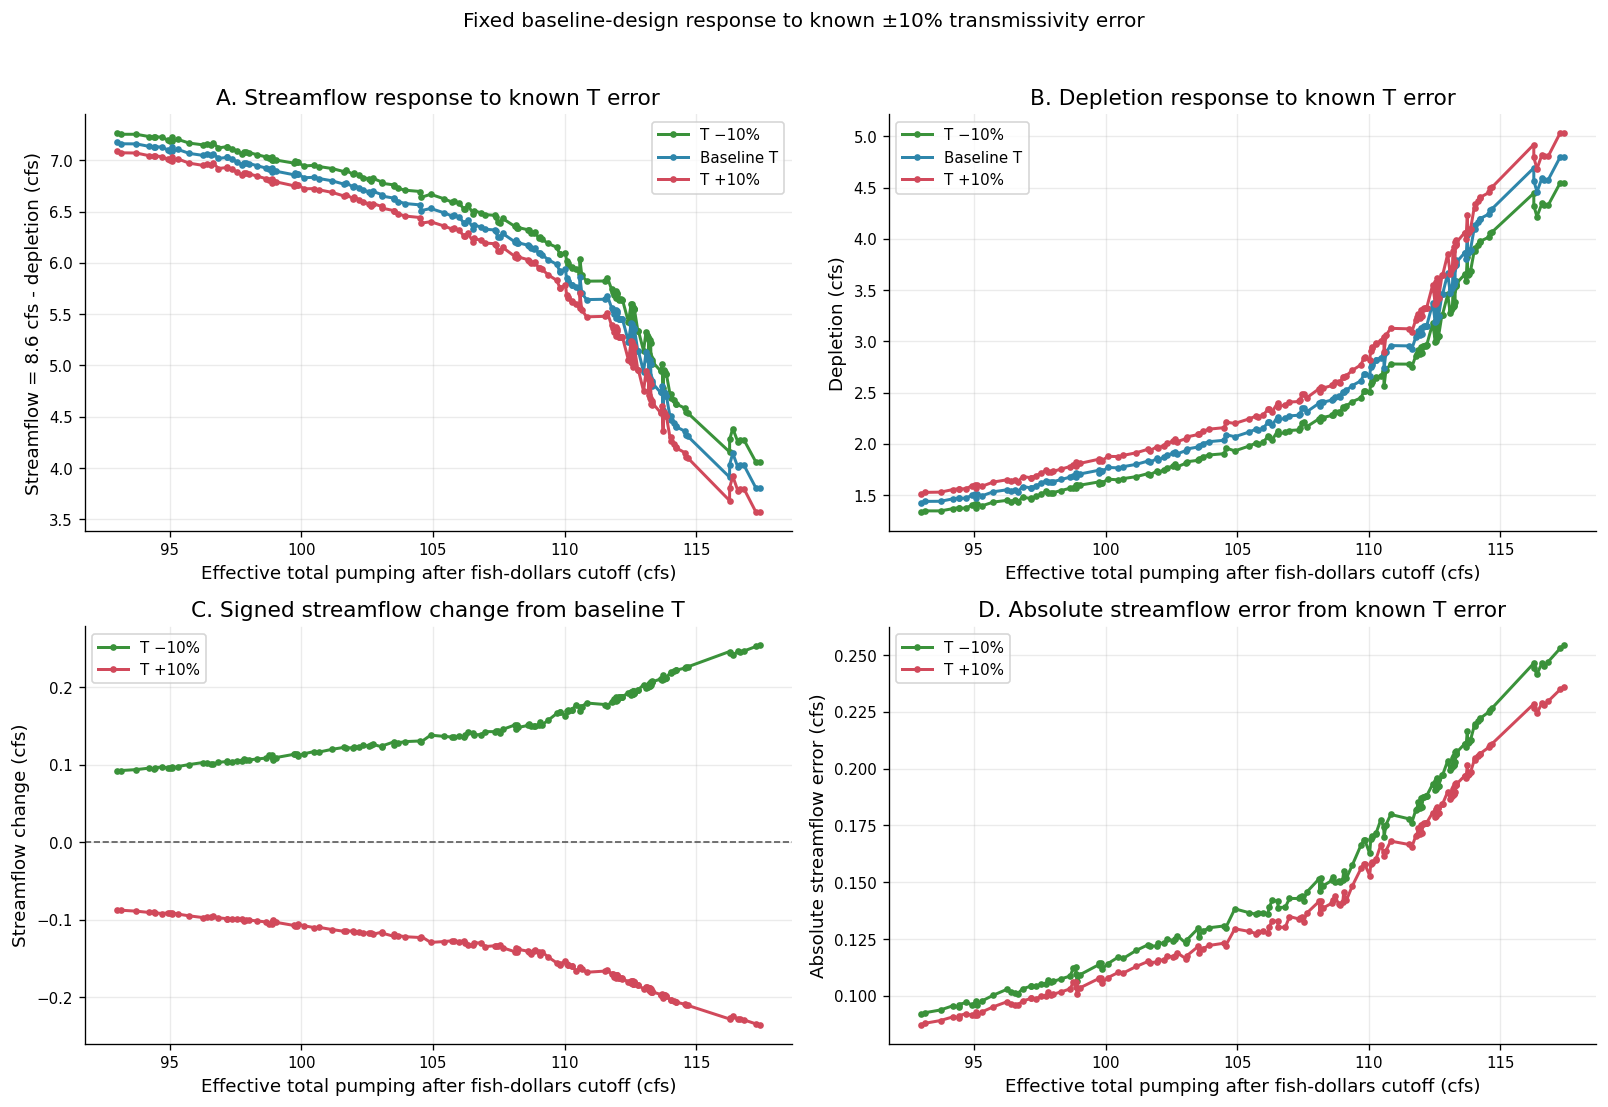

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures/203_known_T_error_response_summary_2x2.png


In [7]:
# -----------------------------------------------------------------------------
# Fixed baseline-design response to known transmissivity error.
# -----------------------------------------------------------------------------
# This reproduces the main 2x2 summary figure from Notebook 201 in the final
# report-figure notebook.
#
# Interpretation:
#   A. Streamflow response:
#      How predicted streamflow changes under each T scenario.
#
#   B. Depletion response:
#      Same information as A, but shown as depletion instead of streamflow.
#
#   C. Signed streamflow change from baseline T:
#      Positive = streamflow is higher than the baseline-T prediction.
#      Negative = streamflow is lower than the baseline-T prediction.
#
#   D. Absolute streamflow error:
#      Magnitude of the streamflow prediction error, regardless of direction.

plot_df = up.sort_for_plot(known_wide, PUMPING_COLUMN_FOR_HYDRO_PLOTS)
x = plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0))
ax_a, ax_b, ax_c, ax_d = axes.ravel()

# -----------------------------------------------------------------------------
# A. Streamflow response
# -----------------------------------------------------------------------------
for scen, ycol in {
    "T_minus_10pct": "streamflow_cfs__T_minus_10pct",
    "baseline_T": "streamflow_cfs__baseline_T",
    "T_plus_10pct": "streamflow_cfs__T_plus_10pct",
}.items():
    if ycol in plot_df.columns:
        ax_a.plot(
            x,
            plot_df[ycol],
            marker="o",
            markersize=3,
            color=SCENARIO_COLORS.get(scen),
            label=SCENARIO_LABELS.get(scen, scen),
        )

ax_a.set_title("A. Streamflow response to known T error")
ax_a.set_xlabel("Effective total pumping after fish-dollars cutoff (cfs)")
ax_a.set_ylabel("Streamflow = 8.6 cfs - depletion (cfs)")
ax_a.legend(loc="best")

# -----------------------------------------------------------------------------
# B. Depletion response
# -----------------------------------------------------------------------------
for scen, ycol in {
    "T_minus_10pct": "depletion_cfs__T_minus_10pct",
    "baseline_T": "depletion_cfs__baseline_T",
    "T_plus_10pct": "depletion_cfs__T_plus_10pct",
}.items():
    if ycol in plot_df.columns:
        ax_b.plot(
            x,
            plot_df[ycol],
            marker="o",
            markersize=3,
            color=SCENARIO_COLORS.get(scen),
            label=SCENARIO_LABELS.get(scen, scen),
        )

ax_b.set_title("B. Depletion response to known T error")
ax_b.set_xlabel("Effective total pumping after fish-dollars cutoff (cfs)")
ax_b.set_ylabel("Depletion (cfs)")
ax_b.legend(loc="best")

# -----------------------------------------------------------------------------
# C. Signed streamflow change from baseline T
# -----------------------------------------------------------------------------
change_specs = {
    "T_minus_10pct": (
        "streamflow_cfs__T_minus_10pct",
        "streamflow_cfs__baseline_T",
    ),
    "T_plus_10pct": (
        "streamflow_cfs__T_plus_10pct",
        "streamflow_cfs__baseline_T",
    ),
}

for scen, (scenario_col, baseline_col) in change_specs.items():
    if scenario_col in plot_df.columns and baseline_col in plot_df.columns:
        signed_change = plot_df[scenario_col] - plot_df[baseline_col]
        ax_c.plot(
            x,
            signed_change,
            marker="o",
            markersize=3,
            color=SCENARIO_COLORS.get(scen),
            label=SCENARIO_LABELS.get(scen, scen),
        )

ax_c.axhline(0, color="0.35", linestyle="--", linewidth=1.0)
ax_c.set_title("C. Signed streamflow change from baseline T")
ax_c.set_xlabel("Effective total pumping after fish-dollars cutoff (cfs)")
ax_c.set_ylabel("Streamflow change (cfs)")
ax_c.legend(loc="best")

# -----------------------------------------------------------------------------
# D. Absolute streamflow error
# -----------------------------------------------------------------------------
for scen, (scenario_col, baseline_col) in change_specs.items():
    if scenario_col in plot_df.columns and baseline_col in plot_df.columns:
        abs_error = (plot_df[scenario_col] - plot_df[baseline_col]).abs()
        ax_d.plot(
            x,
            abs_error,
            marker="o",
            markersize=3,
            color=SCENARIO_COLORS.get(scen),
            label=SCENARIO_LABELS.get(scen, scen),
        )

ax_d.set_title("D. Absolute streamflow error from known T error")
ax_d.set_xlabel("Effective total pumping after fish-dollars cutoff (cfs)")
ax_d.set_ylabel("Absolute streamflow error (cfs)")
ax_d.legend(loc="best")

fig.suptitle(
    "Fixed baseline-design response to known ±10% transmissivity error",
    y=1.02,
)

up.save_figure(
    fig,
    OUTPUT_DIR / "203_known_T_error_response_summary_2x2.png",
)


---
## 8. Probability-weighted uncertainty figures

These plots summarize the unknown-T uncertainty analysis from Notebook `202`.

The streamflow band shows the weighted 5th–95th percentile range caused by uncertainty in T. The cost plots show how much uncertainty matters in terms of expected streamflow error and expected streamflow shortfall.


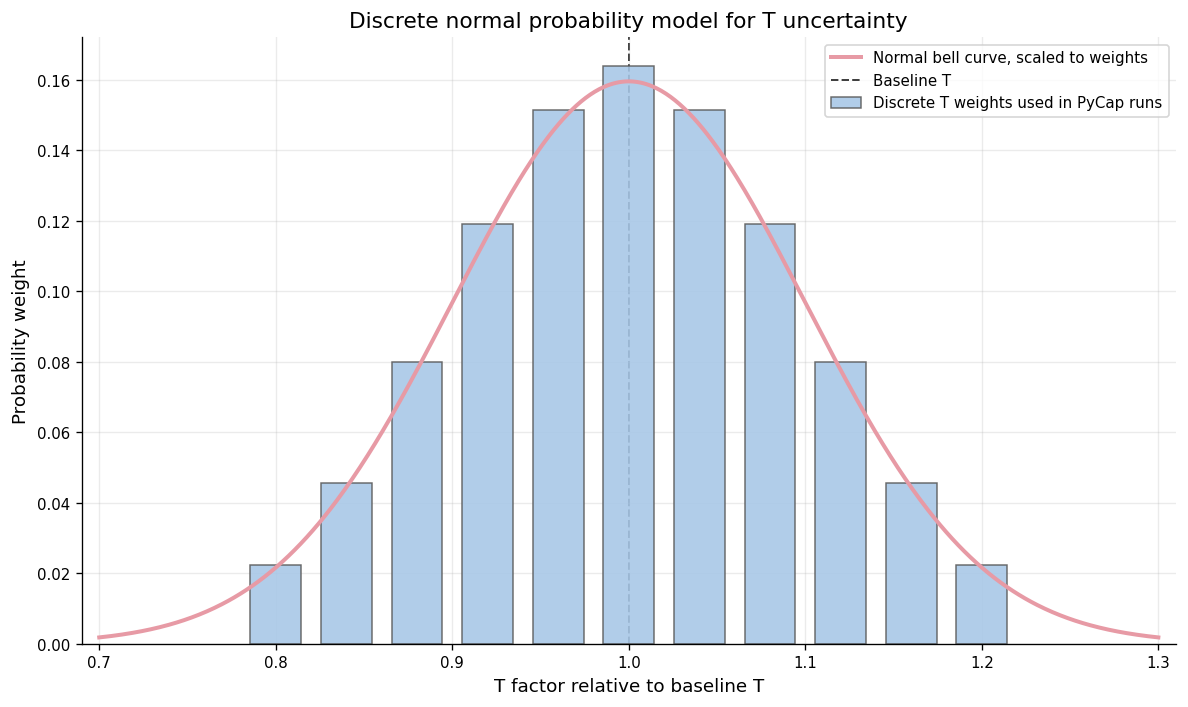

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures/203_T_probability_weights_with_bell_curve.png


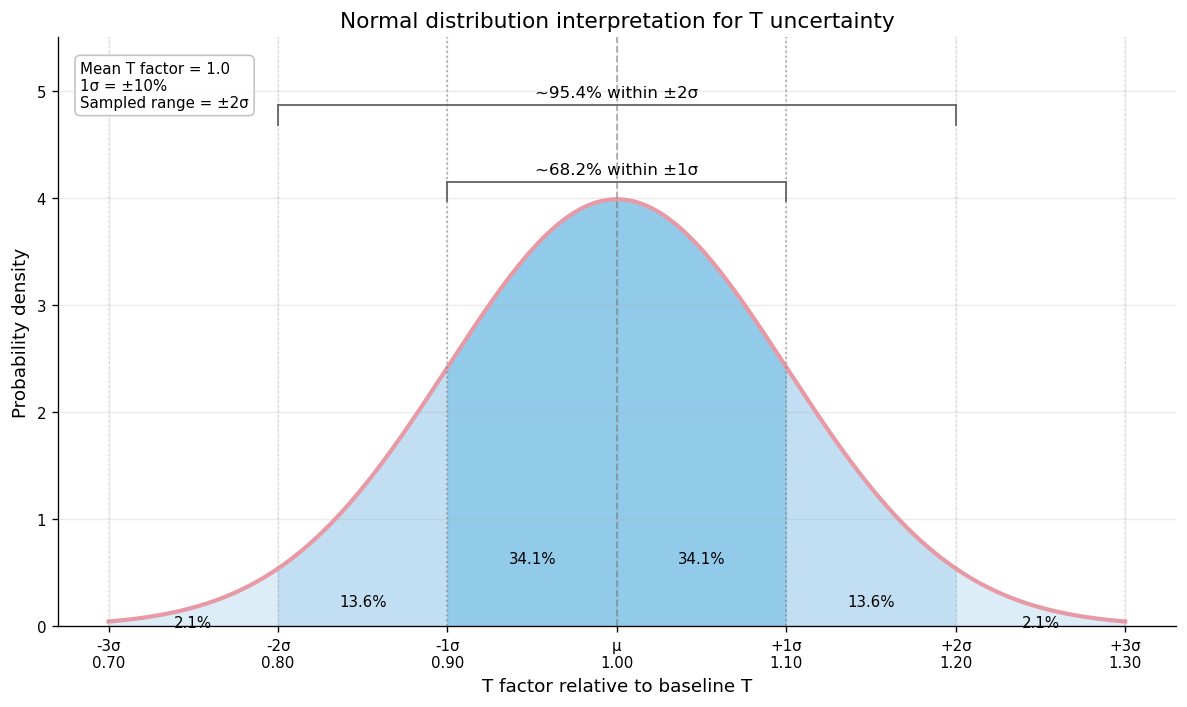

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures/203_T_probability_shaded_sigma_regions.png


/workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/uncertainty_project_helpers.py:924: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


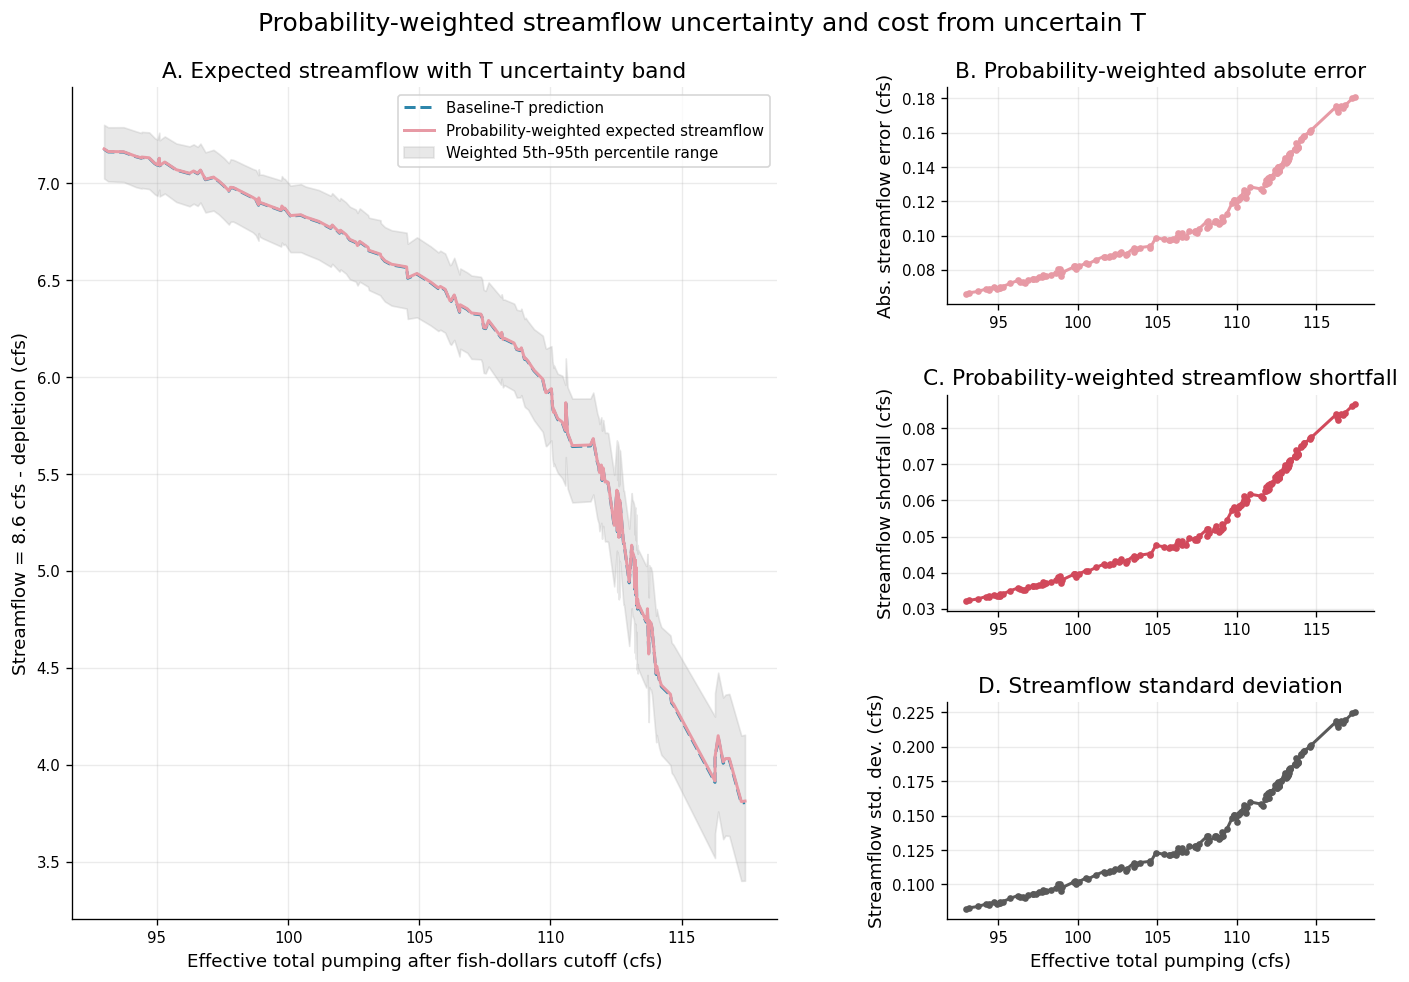

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures/203_probability_weighted_streamflow_dashboard.png


In [8]:
# -----------------------------------------------------------------------------
# Probability model figure: discrete weights + bell curve.
# -----------------------------------------------------------------------------
# This duplicates the useful teaching plot from 202 in the 203 report-figure
# folder so all final figures are available from one place.
# Infer the SAME probability-model parameters used in Notebook 202.
# This avoids drawing an inconsistent bell curve in Notebook 203.
prob_sigma_fraction = up.infer_sigma_fraction_from_probability_table(prob_weights)
prob_n_sigma_each_side = up.infer_n_sigma_each_side_from_probability_table(
    prob_weights, sigma_fraction=prob_sigma_fraction
)

up.plot_T_probability_weights_with_curve(
    T_probability_table=prob_weights,
    sigma_fraction=prob_sigma_fraction,
    outfile=OUTPUT_DIR / "203_T_probability_weights_with_bell_curve.png",
    title="Discrete normal probability model for T uncertainty",
)

# Also duplicate the shaded sigma-interpretation plot from Notebook 202 so the
# final report-figure folder contains both teaching figures.
up.plot_T_probability_shaded_sigma_regions(
    sigma_fraction=prob_sigma_fraction,
    n_sigma_each_side=prob_n_sigma_each_side,
    outfile=OUTPUT_DIR / "203_T_probability_shaded_sigma_regions.png",
    title="Normal distribution interpretation for T uncertainty",
)

# Combined dashboard: left panel = streamflow prediction with uncertainty band;
# right panels = the two main cost metrics.
up.plot_probability_weighted_streamflow_dashboard(
    member_summary=prob_members,
    xcol=PUMPING_COLUMN_FOR_HYDRO_PLOTS,
    outfile=OUTPUT_DIR / "203_probability_weighted_streamflow_dashboard.png",
    title="Probability-weighted streamflow uncertainty and cost from uncertain T",
)


---
## 9. Write a short Markdown results summary

This cell writes a project-results summary file to the `203` output folder. It is not meant to replace your final report, but it gives you a clean starting point for the results section.


In [9]:
# -----------------------------------------------------------------------------
# 9. Write a short Markdown results summary
# -----------------------------------------------------------------------------
# This summary is intentionally interpretive. The goal is not only to report
# values, but also to explain what the values mean for the uncertainty analysis.

def scalar_from_overall(metric_name: str) -> float:
    """Fetch one scalar metric from the 202 overall summary table."""
    row = prob_overall.loc[prob_overall["metric"] == metric_name, "value"]
    return np.nan if row.empty else float(row.iloc[0])


def scenario_row(label: str) -> pd.Series:
    """Fetch one scenario row from the 201 known-T summary table."""
    rows = known_summary.loc[known_summary["scenario"] == label]
    if rows.empty:
        raise KeyError(f"Missing scenario {label!r} from known_summary.")
    return rows.iloc[0]


# Pull the main known-error rows.
baseline_row = scenario_row("baseline_T")
tminus_row = scenario_row("T_minus_10pct")
tplus_row = scenario_row("T_plus_10pct")

# Pull the main probability-weighted uncertainty metrics.
mean_abs_error = scalar_from_overall("mean_probability_weighted_absolute_streamflow_error_cfs")
max_abs_error = scalar_from_overall("max_probability_weighted_absolute_streamflow_error_cfs")
mean_shortfall = scalar_from_overall("mean_probability_weighted_streamflow_shortfall_cfs")
max_shortfall = scalar_from_overall("max_probability_weighted_streamflow_shortfall_cfs")
mean_std = scalar_from_overall("mean_streamflow_std_cfs")
max_std = scalar_from_overall("max_streamflow_std_cfs")

# Values used in the written interpretation.
baseline_mean_streamflow = baseline_row["mean_streamflow_cfs"]
baseline_mean_depletion = baseline_row["mean_depletion_cfs"]

tminus_mean_change = tminus_row["mean_streamflow_change_from_baseline_cfs"]
tplus_mean_change = tplus_row["mean_streamflow_change_from_baseline_cfs"]

tminus_max_error = tminus_row["max_absolute_streamflow_error_cfs"]
tplus_max_error = tplus_row["max_absolute_streamflow_error_cfs"]

depletion_obs_label = getattr(up, "DEPLETION_OBS_NAME", "lpr:total_combined:bdpl")

# Optional note about the original MOU fronts.
if "original_tradeoffs" in globals() and not original_tradeoffs.empty:
    scen_list = ", ".join(original_tradeoffs["scenario"].drop_duplicates().astype(str).tolist())
    original_note = (
        f"Original 05_MOU tradeoff fronts were loaded for: {scen_list}. "
        "These represent fully re-optimized Pareto fronts under each T scenario. "
        "In contrast, the fixed-design re-evaluations hold the baseline Pareto-front "
        "pumping designs constant and only change T during re-evaluation."
    )
else:
    original_note = (
        "Original 05_MOU tradeoff fronts were not loaded in this run. Therefore, "
        "this summary focuses on the fixed-design known-error analysis and the "
        "probability-weighted T uncertainty analysis."
    )


summary_text = f"""# Project Results Summary — Transmissivity Uncertainty

## Purpose of the analysis

This analysis evaluates how uncertainty in transmissivity (T) affects the hydrologic performance of baseline Pareto-front pumping designs from the fish-dollars PyCap optimization.

The main hydrologic metrics are:

- Total pumping, expressed as effective pumping after the fish-dollars cutoff rule.
- Depletion, represented by `{depletion_obs_label}`.
- Streamflow, calculated as streamflow = 8.6 cfs - depletion.

The analysis is separated into two related questions:

1. Known T error: What happens if T is actually 10% lower or 10% higher than the baseline value?
2. Unknown T uncertainty: What is the probability-weighted streamflow cost when T is treated as uncertain?

---

## Fixed baseline Pareto designs under known T error

The baseline fish-dollars Pareto-front designs were held fixed and re-evaluated hydrologically under alternate transmissivity assumptions.

| Scenario | T value | Mean streamflow (cfs) | Mean depletion (cfs) | Mean streamflow change from baseline (cfs) | Max absolute streamflow error (cfs) |
|---|---:|---:|---:|---:|---:|
| T -10% | {tminus_row['T_value']:.1f} | {tminus_row['mean_streamflow_cfs']:.6f} | {tminus_row['mean_depletion_cfs']:.6f} | {tminus_row['mean_streamflow_change_from_baseline_cfs']:.6f} | {tminus_row['max_absolute_streamflow_error_cfs']:.6f} |
| Baseline T | {baseline_row['T_value']:.1f} | {baseline_row['mean_streamflow_cfs']:.6f} | {baseline_row['mean_depletion_cfs']:.6f} | {baseline_row['mean_streamflow_change_from_baseline_cfs']:.6f} | {baseline_row['max_absolute_streamflow_error_cfs']:.6f} |
| T +10% | {tplus_row['T_value']:.1f} | {tplus_row['mean_streamflow_cfs']:.6f} | {tplus_row['mean_depletion_cfs']:.6f} | {tplus_row['mean_streamflow_change_from_baseline_cfs']:.6f} | {tplus_row['max_absolute_streamflow_error_cfs']:.6f} |

### Interpretation

For the fixed baseline Pareto designs, the direction of the T effect is consistent:

- Lower T (-10%) produced less depletion and higher streamflow.
- Higher T (+10%) produced more depletion and lower streamflow.

This means that, for this model setup, assuming the baseline T when the true T is higher would tend to overestimate streamflow and underestimate depletion. That is the more management-relevant risk direction because it makes the stream appear less impacted than it would be under the higher-T assumption.

The mean baseline streamflow across the fixed designs was {baseline_mean_streamflow:.6f} cfs, with mean depletion of {baseline_mean_depletion:.6f} cfs. Relative to that baseline:

- T -10% changed mean streamflow by {tminus_mean_change:.6f} cfs.
- T +10% changed mean streamflow by {tplus_mean_change:.6f} cfs.

The maximum absolute streamflow errors were:

- {tminus_max_error:.6f} cfs for T -10%.
- {tplus_max_error:.6f} cfs for T +10%.

---

## Probability-weighted unknown T uncertainty

The unknown-T analysis treated transmissivity as a discrete normal probability model centered on the baseline T value. Each baseline Pareto design was re-evaluated across sampled T values, and the resulting streamflow values were weighted by the probability assigned to each T value.

| Metric | Value (cfs) |
|---|---:|
| Mean probability-weighted absolute streamflow error | {mean_abs_error:.6f} |
| Max probability-weighted absolute streamflow error | {max_abs_error:.6f} |
| Mean probability-weighted streamflow shortfall | {mean_shortfall:.6f} |
| Max probability-weighted streamflow shortfall | {max_shortfall:.6f} |
| Mean streamflow standard deviation | {mean_std:.6f} |
| Max streamflow standard deviation | {max_std:.6f} |

### Interpretation

The probability-weighted absolute streamflow error represents the expected magnitude of streamflow error caused by uncertainty in T. It treats streamflow being too high or too low as equally important.

The probability-weighted streamflow shortfall is more conservative and management-focused. It only counts cases where uncertain T produces lower streamflow than the baseline-T prediction. This is useful because lower-than-expected streamflow is the risk direction most relevant to ecological flow protection.

The probability-weighted results show that T uncertainty introduces a measurable but relatively bounded amount of streamflow uncertainty across the baseline Pareto designs. The largest uncertainty costs occur where the design is most sensitive to T, rather than being uniform across the full Pareto front.

---

## Original MOU front comparison

{original_note}

The original-front comparison and fixed-design re-evaluation answer different questions:

- Fixed-design re-evaluation: What happens to the already-selected baseline Pareto designs if T is wrong?
- Original MOU comparison: How does the optimized tradeoff front move when the model is re-optimized under a different T?

This distinction matters. If the fixed baseline designs plot far from the re-optimized front for the same T scenario, that indicates potential optimality loss or cost of wrongness. In other words, the selected design can still be evaluated under the corrected T value, but it may no longer represent the best tradeoff under that corrected T assumption.

---

## Main finding

The main finding is that transmissivity uncertainty affects the predicted streamflow/depletion tradeoff even when pumping designs are held fixed. Higher transmissivity tends to increase depletion and reduce streamflow for the same baseline Pareto designs. Therefore, uncertainty in T can create both hydrologic prediction error and management risk, especially when the baseline design is evaluated under a T value that differs from the true system behavior.

The probability-weighted analysis extends this by summarizing uncertainty across a distribution of possible T values, rather than only evaluating the two known-error cases. This provides a compact way to describe the expected cost of T uncertainty for each Pareto-front design.
"""

summary_path = OUTPUT_DIR / "203_project_results_summary.md"
summary_path.write_text(summary_text)

print(summary_text)
print("Saved:", summary_path)

# Project Results Summary — Transmissivity Uncertainty

## Purpose of the analysis

This analysis evaluates how uncertainty in transmissivity (T) affects the hydrologic performance of baseline Pareto-front pumping designs from the fish-dollars PyCap optimization.

The main hydrologic metrics are:

- Total pumping, expressed as effective pumping after the fish-dollars cutoff rule.
- Depletion, represented by `lpr:total_combined:bdpl`.
- Streamflow, calculated as streamflow = 8.6 cfs - depletion.

The analysis is separated into two related questions:

1. Known T error: What happens if T is actually 10% lower or 10% higher than the baseline value?
2. Unknown T uncertainty: What is the probability-weighted streamflow cost when T is treated as uncertain?

---

## Fixed baseline Pareto designs under known T error

The baseline fish-dollars Pareto-front designs were held fixed and re-evaluated hydrologically under alternate transmissivity assumptions.

| Scenario | T value | Mean streamflow (

---
## 10. List final outputs

This final cell prints every file saved by the notebook so you can quickly check what was generated.


In [10]:
print("All files saved in:")
print(OUTPUT_DIR)
print("\nFiles:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f.name)


All files saved in:
/workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/203_uncertainty_report_figures

Files:
 - 203_T_probability_shaded_sigma_regions.png
 - 203_T_probability_weights_with_bell_curve.png
 - 203_compact_uncertainty_summary.csv
 - 203_fixed_design_vs_original_MOU_fronts_2x2.png
 - 203_known_T_error_response_summary_2x2.png
 - 203_original_vs_reevaluated_fronts_depletion_1x3.png
 - 203_original_vs_reevaluated_fronts_streamflow_1x3.png
 - 203_probability_weighted_streamflow_dashboard.png
 - 203_project_results_summary.md
 - 203_representative_pareto_designs.csv
